In [28]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import torch
torch.cuda.is_available()
from keras.models import Sequential, Model
from keras.layers import (Dense, Input, Flatten, Reshape, Rescaling, Conv2D, MaxPooling2D, GlobalAveragePooling2D, 
                          Dropout, RandomFlip, RandomRotation, RandomCrop, RandomShear, RandomZoom, RandomContrast, RandomTranslation, RandomErasing)
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, RMSprop
from keras.metrics import Accuracy
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [29]:
print("Keras:", keras.__version__)
print("Backend:", keras.backend.backend())

x = keras.ops.ones((2, 32, 32, 3))

crop = keras.layers.RandomCrop(26, 26)

y = crop(x, training=True)

print(y.shape)

Keras: 3.15.1
Backend: torch
torch.Size([2, 26, 26, 3])


In [30]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train,y_train, train_size= 0.8, random_state=1)


In [31]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


In [32]:
class_names= [
"airplane",
"automobile",
"bird",
"cat",
"deer",
"dog",
"frog",
"horse",
"ship",
"truck"
]

In [33]:
kernel_size = (3,3)
strides = (1,1)

# x_train = x_train.float()
# x_val = x_val.float()

def build_model(activation: str = 'relu') -> Sequential:
  model = Sequential([
    Input(shape=(32,32,3)),

    RandomFlip('vertical'),
    # RandomTranslation(0.1, 0.1),
    RandomErasing(factor=0.5, scale=(0.1, 0.25)),
    # RandomZoom(0.2),
    # RandomCrop(26, 26),


    Rescaling(1./255), # place every value from 0 to 255 to between 0 and 1


    Conv2D(64,kernel_size,1,'same', activation=activation),
    Conv2D(64,kernel_size,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    Conv2D(128,kernel_size,1,'same', activation=activation),
    Conv2D(128,kernel_size,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    Conv2D(256,kernel_size,1,'same', activation=activation),
    Conv2D(256,kernel_size,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    # Flatten(),
    
    # Dense(64, activation='relu'),
    # Dropout(0.5),


    Dense(10, activation='softmax'), #10 categories
  
  ])


  model.compile(optimizer=Adam(), 
                loss=SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

  return model


model = build_model()
model.summary()


callbacks = [
  ModelCheckpoint('best.keras', monitor='val_loss', mode='auto', save_best_only=True ),
  EarlyStopping(monitor='val_loss', min_delta=2, patience=1)
]


  

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_11 (RandomFlip)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing_11               │ (None, 32, 32, 3)      │             0 │
│ (RandomErasing)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,147,978 (4.38 MB)

 Trainable params: 1,147,978 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.fit(x_train, y_train, batch_size=256, epochs=2, validation_data=(x_val, y_val), callbacks=callbacks)

Epoch 1/2


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4454 - loss: 1.4789

I0000 00:00:1789545964.725358    8546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789545964.981270    8546 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.4454 - loss: 1.4789 - val_accuracy: 0.4921 - val_loss: 1.3665
Epoch 2/2


I0000 00:00:1789545967.367809    8546 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789545967.370019    8546 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.4909 - loss: 1.3667 - val_accuracy: 0.5191 - val_loss: 1.2869


In [37]:
from keras.models import load_model, save_model

best_model = load_model('best.keras')
best_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_11 (RandomFlip)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_erasing_11               │ (None, 32, 32, 3)      │             0 │
│ (RandomErasing)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,443,936 (13.14 MB)

 Trainable params: 1,147,978 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,295,958 (8.76 MB)

In [ ]:
def plot_evaluation(history: dict, metrics: list[str] = ['accuracy']) -> None:
  metrics.append('loss')

  for metric in metrics:
    plt.Figure(figsize=(10,7))
    plt.lineplot(history[metric], label="train")
    plt.lineplot(history[f'val_{metric}'], label="val")
    plt.show()

plot_evaluation(model.history.history)

/tmp/ipykernel_25061/1918531191.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(model.layers[-1].weights[0]).ravel())


<Axes: ylabel='Density'>

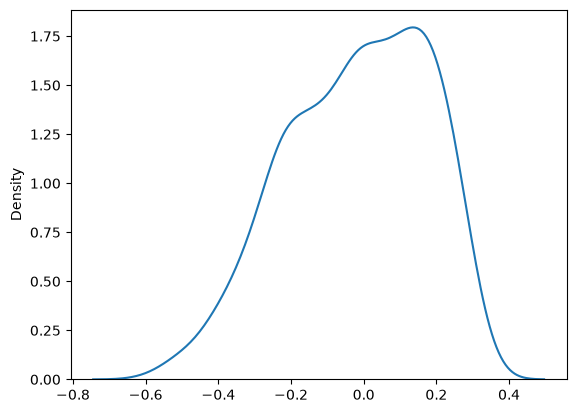

In [ ]:
sns.kdeplot(np.array(model.layers[-1].weights[0]).ravel())

In [ ]:
print(torch.cuda.is_available())

True


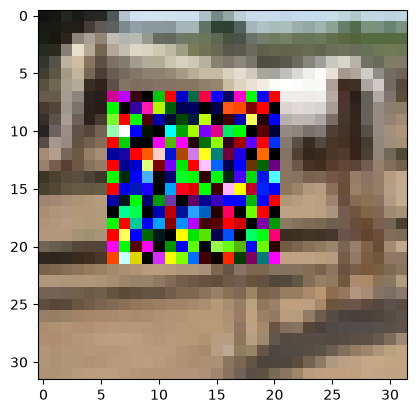

In [10]:
data_augmenter = Sequential([
  RandomFlip('vertical'),
  RandomErasing()
])

sample_batch = x_train[:16]
img_augmented = data_augmenter(sample_batch, training = True).cpu().numpy().astype(np.uint8)
img_augmented.shape
plt.imshow(img_augmented[0])
